<a href="https://colab.research.google.com/github/lenguyen31241026402-droid/bt-al-2/blob/main/BT_Al_2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- KẾT QUẢ BÀI 2.11 ---
Khoảng cách đầu vào: 12 km
Mức độ nhu cầu đầu vào: 75%
Giá cước dự toán (y): 281.35 (nghìn đồng)


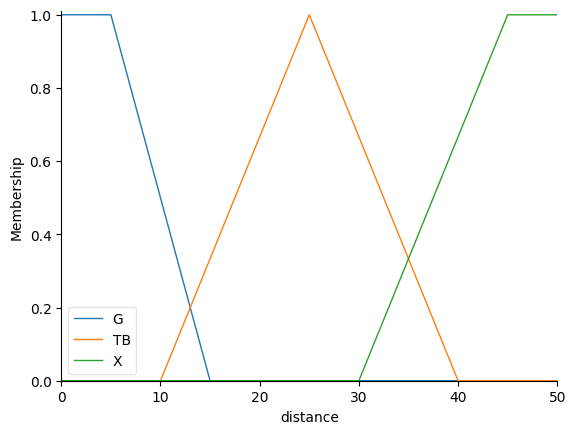

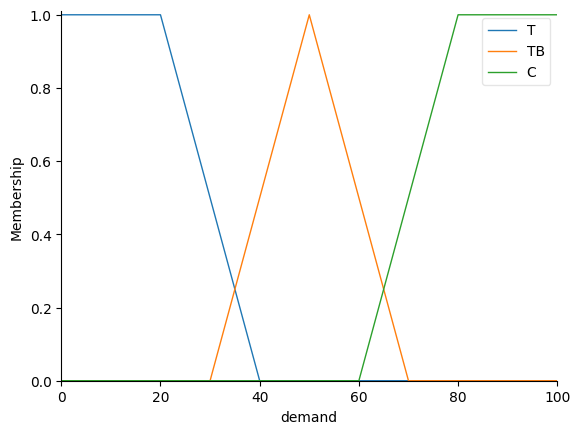

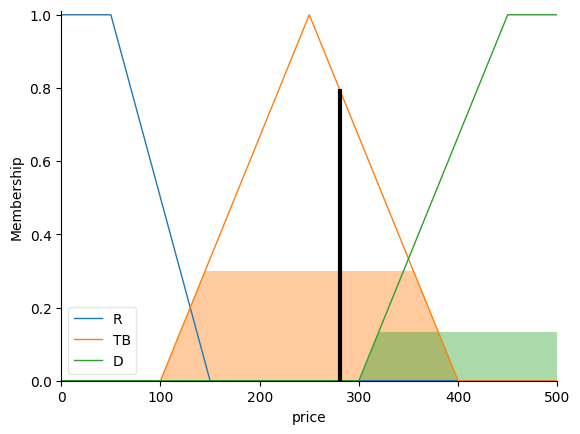

In [5]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Xác định biến đầu vào và đầu ra
# Khoảng cách (x1): 0 - 50 km
# Mức độ nhu cầu (x2): 0 - 100 %
# Giá cước (y): 0 - 500 (nghìn đồng)
distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
price = ctrl.Consequent(np.arange(0, 501, 1), 'price')

# 2. Định nghĩa các hàm thành viên (Fuzzification)
# Khoảng cách (x1)
distance['G'] = fuzz.trapmf(distance.universe, [0, 0, 5, 15])
distance['TB'] = fuzz.trimf(distance.universe, [10, 25, 40])
distance['X'] = fuzz.trapmf(distance.universe, [30, 45, 50, 50])

# Mức độ nhu cầu (x2)
demand['T'] = fuzz.trapmf(demand.universe, [0, 0, 20, 40])
demand['TB'] = fuzz.trimf(demand.universe, [30, 50, 70])
demand['C'] = fuzz.trapmf(demand.universe, [60, 80, 100, 100])

# Giá cước (y)
price['R'] = fuzz.trapmf(price.universe, [0, 0, 50, 150])
price['TB'] = fuzz.trimf(price.universe, [100, 250, 400])
price['D'] = fuzz.trapmf(price.universe, [300, 450, 500, 500])

# 3. Xây dựng tập luật (9 luật)
rules = [
    ctrl.Rule(distance['G'] & demand['T'], price['R']),
    ctrl.Rule(distance['G'] & demand['TB'], price['R']),
    ctrl.Rule(distance['G'] & demand['C'], price['TB']),

    ctrl.Rule(distance['TB'] & demand['T'], price['R']),
    ctrl.Rule(distance['TB'] & demand['TB'], price['TB']),
    ctrl.Rule(distance['TB'] & demand['C'], price['D']),

    ctrl.Rule(distance['X'] & demand['T'], price['TB']),
    ctrl.Rule(distance['X'] & demand['TB'], price['D']),
    ctrl.Rule(distance['X'] & demand['C'], price['D'])
]

# 4. Hệ thống điều khiển và mô phỏng
grab_bike_ctrl = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(grab_bike_ctrl)

# 5. Giải mờ và kiểm tra với ví dụ
# Đầu vào: x1 = 12 km, x2 = 75 %
simulation.input['distance'] = 12
simulation.input['demand'] = 75

# Tính toán
simulation.compute()

# Kết quả
print(f"--- KẾT QUẢ BÀI 2.11 ---")
print(f"Khoảng cách đầu vào: 12 km")
print(f"Mức độ nhu cầu đầu vào: 75%")
print(f"Giá cước dự toán (y): {simulation.output['price']:.2f} (nghìn đồng)")

# Hiển thị đồ thị (Tùy chọn để xem trực quan)
distance.view()
demand.view()
price.view(sim=simulation)
plt.show()

--- KẾT QUẢ BÀI 2.12 ---
Đánh giá khách hàng (x1): 4.2 sao
Uy tín cửa hàng (x2): 65 điểm
Mức giảm giá đề xuất (y): 6.89%


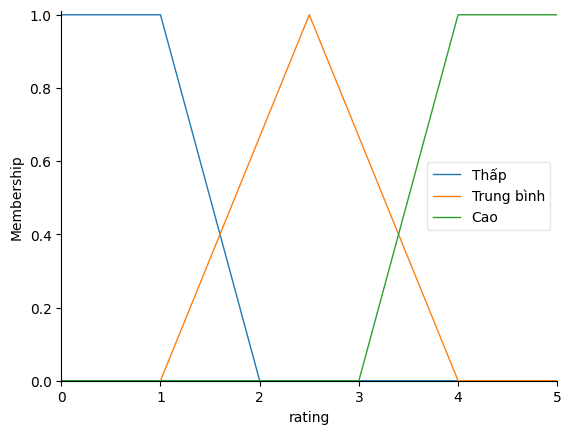

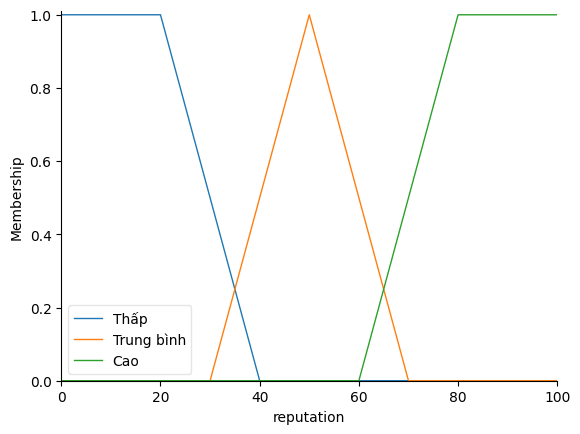

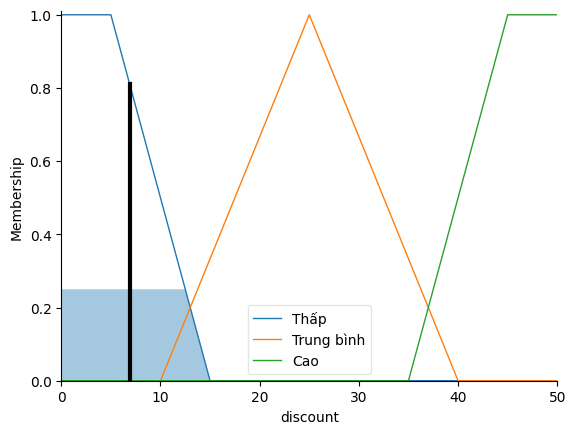

In [6]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Xác định biến đầu vào và đầu ra
# x1: Đánh giá trung bình từ khách hàng (0 - 5 sao)
# x2: Uy tín của cửa hàng (0 - 100 điểm)
# y: Phần trăm giảm giá (0 - 50 %)
rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
reputation = ctrl.Antecedent(np.arange(0, 101, 1), 'reputation')
discount = ctrl.Consequent(np.arange(0, 51, 1), 'discount')

# 2. Định nghĩa các hàm thành viên

# Đánh giá (x1)
rating['Thấp'] = fuzz.trapmf(rating.universe, [0, 0, 1, 2])
rating['Trung bình'] = fuzz.trimf(rating.universe, [1, 2.5, 4])
rating['Cao'] = fuzz.trapmf(rating.universe, [3, 4, 5, 5])

# Uy tín (x2)
reputation['Thấp'] = fuzz.trapmf(reputation.universe, [0, 0, 20, 40])
reputation['Trung bình'] = fuzz.trimf(reputation.universe, [30, 50, 70])
reputation['Cao'] = fuzz.trapmf(reputation.universe, [60, 80, 100, 100])

# Giảm giá (y)
discount['Thấp'] = fuzz.trapmf(discount.universe, [0, 0, 5, 15])
discount['Trung bình'] = fuzz.trimf(discount.universe, [10, 25, 40])
discount['Cao'] = fuzz.trapmf(discount.universe, [35, 45, 50, 50])

# 3. Thiết lập 9 luật hợp thành (Rules)
rules = [
    ctrl.Rule(rating['Thấp'] & reputation['Thấp'], discount['Cao']),
    ctrl.Rule(rating['Thấp'] & reputation['Trung bình'], discount['Cao']),
    ctrl.Rule(rating['Thấp'] & reputation['Cao'], discount['Trung bình']),

    ctrl.Rule(rating['Trung bình'] & reputation['Thấp'], discount['Cao']),
    ctrl.Rule(rating['Trung bình'] & reputation['Trung bình'], discount['Trung bình']),
    ctrl.Rule(rating['Trung bình'] & reputation['Cao'], discount['Thấp']),

    ctrl.Rule(rating['Cao'] & reputation['Thấp'], discount['Trung bình']),
    ctrl.Rule(rating['Cao'] & reputation['Trung bình'], discount['Thấp']),
    ctrl.Rule(rating['Cao'] & reputation['Cao'], discount['Thấp'])
]

# 4. Tạo hệ thống điều khiển và mô phỏng
shopee_ctrl = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(shopee_ctrl)

# 5. Giải mờ cho trường hợp cụ thể
# Ví dụ: x1 = 4.2 sao, x2 = 65 điểm
simulation.input['rating'] = 4.2
simulation.input['reputation'] = 65

# Thực hiện tính toán
simulation.compute()

# Kết quả cuối cùng
print(f"--- KẾT QUẢ BÀI 2.12 ---")
print(f"Đánh giá khách hàng (x1): 4.2 sao")
print(f"Uy tín cửa hàng (x2): 65 điểm")
print(f"Mức giảm giá đề xuất (y): {simulation.output['discount']:.2f}%")

# Hiển thị biểu đồ trực quan
rating.view()
reputation.view()
discount.view(sim=simulation)
plt.show()

--- KẾT QUẢ BÀI 2.13 ---
Đánh giá khách hàng (x1): 3.5 sao
Uy tín cửa hàng (x2): 45 điểm
Biên lợi nhuận gộp dự toán (y): 17.15%


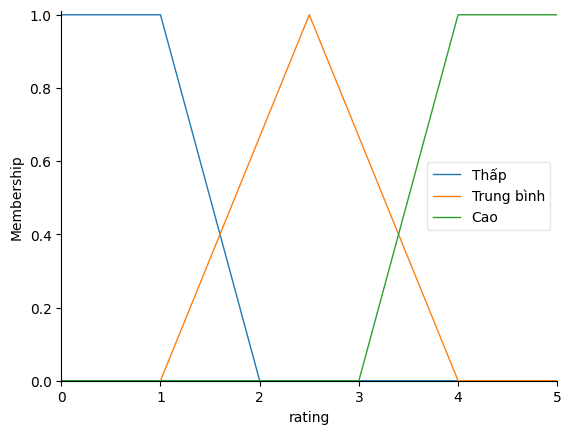

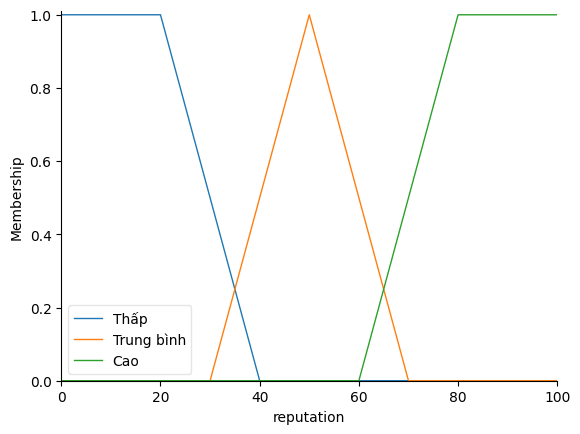

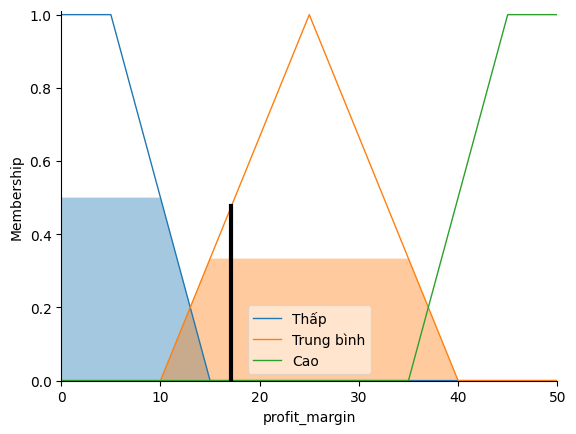

In [7]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Xác định biến đầu vào và đầu ra
# x1: Đánh giá trung bình từ khách hàng (0 - 5 sao)
# x2: Uy tín của cửa hàng (0 - 100 điểm)
# y: Biên lợi nhuận gộp (0 - 50 %)
rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
reputation = ctrl.Antecedent(np.arange(0, 101, 1), 'reputation')
profit_margin = ctrl.Consequent(np.arange(0, 51, 1), 'profit_margin')

# 2. Định nghĩa các hàm thành viên

# Đánh giá khách hàng (x1)
rating['Thấp'] = fuzz.trapmf(rating.universe, [0, 0, 1, 2])
rating['Trung bình'] = fuzz.trimf(rating.universe, [1, 2.5, 4])
rating['Cao'] = fuzz.trapmf(rating.universe, [3, 4, 5, 5])

# Uy tín cửa hàng (x2)
reputation['Thấp'] = fuzz.trapmf(reputation.universe, [0, 0, 20, 40])
reputation['Trung bình'] = fuzz.trimf(reputation.universe, [30, 50, 70])
reputation['Cao'] = fuzz.trapmf(reputation.universe, [60, 80, 100, 100])

# Biên lợi nhuận gộp (y)
profit_margin['Thấp'] = fuzz.trapmf(profit_margin.universe, [0, 0, 5, 15])
profit_margin['Trung bình'] = fuzz.trimf(profit_margin.universe, [10, 25, 40])
profit_margin['Cao'] = fuzz.trapmf(profit_margin.universe, [35, 45, 50, 50])

# 3. Thiết lập bảng 9 luật hợp thành (Rules)
rules = [
    ctrl.Rule(rating['Thấp'] & reputation['Thấp'], profit_margin['Cao']),
    ctrl.Rule(rating['Thấp'] & reputation['Trung bình'], profit_margin['Cao']),
    ctrl.Rule(rating['Thấp'] & reputation['Cao'], profit_margin['Trung bình']),

    ctrl.Rule(rating['Trung bình'] & reputation['Thấp'], profit_margin['Cao']),
    ctrl.Rule(rating['Trung bình'] & reputation['Trung bình'], profit_margin['Trung bình']),
    ctrl.Rule(rating['Trung bình'] & reputation['Cao'], profit_margin['Thấp']),

    ctrl.Rule(rating['Cao'] & reputation['Thấp'], profit_margin['Trung bình']),
    ctrl.Rule(rating['Cao'] & reputation['Trung bình'], profit_margin['Thấp']),
    ctrl.Rule(rating['Cao'] & reputation['Cao'], profit_margin['Thấp'])
]

# 4. Tạo hệ thống điều khiển và mô phỏng
profit_ctrl = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(profit_ctrl)

# 5. Tính toán cho trường hợp cụ thể
# Đầu vào: x1 = 3.5 sao, x2 = 45 điểm
simulation.input['rating'] = 3.5
simulation.input['reputation'] = 45

# Thực hiện giải mờ (Defuzzification)
simulation.compute()

# Kết quả
print(f"--- KẾT QUẢ BÀI 2.13 ---")
print(f"Đánh giá khách hàng (x1): 3.5 sao")
print(f"Uy tín cửa hàng (x2): 45 điểm")
print(f"Biên lợi nhuận gộp dự toán (y): {simulation.output['profit_margin']:.2f}%")

# Hiển thị đồ thị trực quan
rating.view()
reputation.view()
profit_margin.view(sim=simulation)
plt.show()

--- KẾT QUẢ BÀI 2.14 ---
Mật độ đơn hàng (x1): 85%
Tải trọng tài xế (x2): 25%
Số lượng đơn nên kết hợp (y): 6.00 đơn


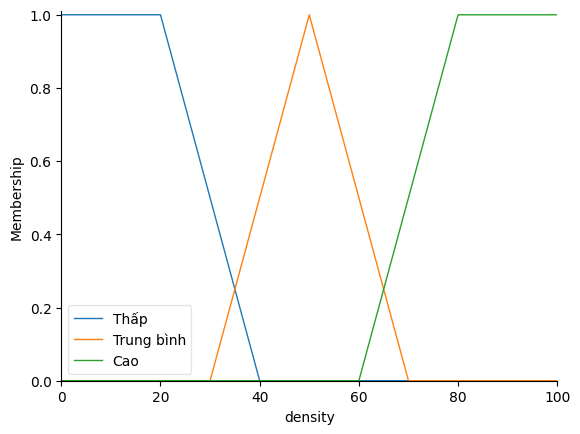

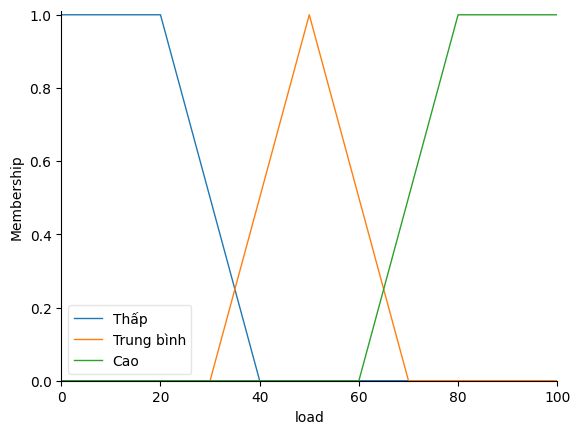

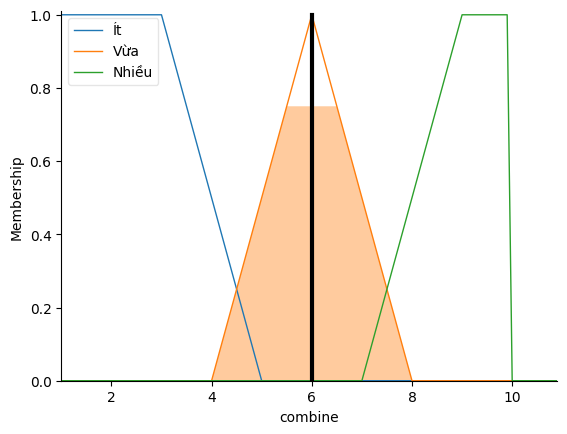

In [8]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Xác định biến đầu vào và đầu ra
# x1: Mật độ đơn hàng (0 - 100 %)
# x2: Tải trọng tài xế (0 - 100 %)
# y: Số lượng đơn hàng cần kết hợp (1 - 10 đơn)
density = ctrl.Antecedent(np.arange(0, 101, 1), 'density')
load = ctrl.Antecedent(np.arange(0, 101, 1), 'load')
combine = ctrl.Consequent(np.arange(1, 11, 0.1), 'combine')

# 2. Định nghĩa các hàm thành viên

# Mật độ đơn hàng (x1)
density['Thấp'] = fuzz.trapmf(density.universe, [0, 0, 20, 40])
density['Trung bình'] = fuzz.trimf(density.universe, [30, 50, 70])
density['Cao'] = fuzz.trapmf(density.universe, [60, 80, 100, 100])

# Tải trọng tài xế (x2)
load['Thấp'] = fuzz.trapmf(load.universe, [0, 0, 20, 40])
load['Trung bình'] = fuzz.trimf(load.universe, [30, 50, 70])
load['Cao'] = fuzz.trapmf(load.universe, [60, 80, 100, 100])

# Số đơn kết hợp (y)
combine['Ít'] = fuzz.trapmf(combine.universe, [1, 1, 3, 5])
combine['Vừa'] = fuzz.trimf(combine.universe, [4, 6, 8])
combine['Nhiều'] = fuzz.trapmf(combine.universe, [7, 9, 10, 10])

# 3. Thiết lập 9 luật hợp thành (Rules)
rules = [
    ctrl.Rule(density['Thấp'] & load['Thấp'], combine['Ít']),
    ctrl.Rule(density['Thấp'] & load['Trung bình'], combine['Ít']),
    ctrl.Rule(density['Thấp'] & load['Cao'], combine['Vừa']),

    ctrl.Rule(density['Trung bình'] & load['Thấp'], combine['Ít']),
    ctrl.Rule(density['Trung bình'] & load['Trung bình'], combine['Vừa']),
    ctrl.Rule(density['Trung bình'] & load['Cao'], combine['Nhiều']),

    ctrl.Rule(density['Cao'] & load['Thấp'], combine['Vừa']),
    ctrl.Rule(density['Cao'] & load['Trung bình'], combine['Nhiều']),
    ctrl.Rule(density['Cao'] & load['Cao'], combine['Nhiều'])
]

# 4. Tạo hệ thống điều khiển và mô phỏng
delivery_ctrl = ctrl.ControlSystem(rules)
simulation = ctrl.ControlSystemSimulation(delivery_ctrl)

# 5. Giải mờ cho trường hợp cụ thể
# Đầu vào: x1 = 85%, x2 = 25%
simulation.input['density'] = 85
simulation.input['load'] = 25

# Thực hiện tính toán
simulation.compute()

# Kết quả cuối cùng
print(f"--- KẾT QUẢ BÀI 2.14 ---")
print(f"Mật độ đơn hàng (x1): 85%")
print(f"Tải trọng tài xế (x2): 25%")
print(f"Số lượng đơn nên kết hợp (y): {simulation.output['combine']:.2f} đơn")

# Hiển thị đồ thị (Tùy chọn)
density.view()
load.view()
combine.view(sim=simulation)
plt.show()